### Eda using seaborn - housing price dataset

In [51]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv("data/housing.csv")

In [53]:
df.head().style.background_gradient(cmap='YlOrRd')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [54]:
# dataframe shape
df.shape

(545, 13)

In [55]:
# dataframe columns
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [56]:
# dataframe info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [57]:
# check null values
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [58]:
# statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


**Univaraite Analyis**
- Univariate data refers to a dataset where each observation is assoiated with only one variable

In [59]:
df["bedrooms"].value_counts()

bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64

In [60]:
df["bathrooms"].value_counts()

bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64

In [61]:
df["stories"].value_counts() # no of floors

stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64

In [62]:
df["parking"].value_counts()

parking
0    299
1    126
2    108
3     12
Name: count, dtype: int64

**bar plot**

In [63]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

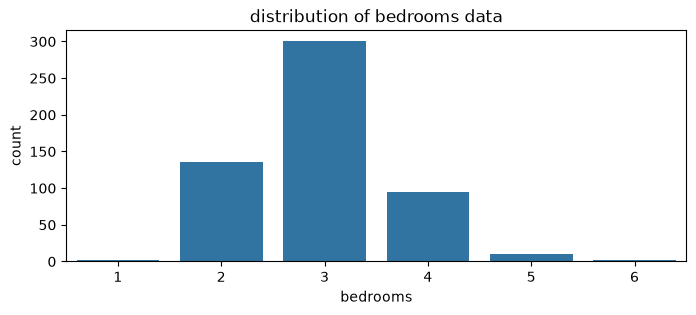

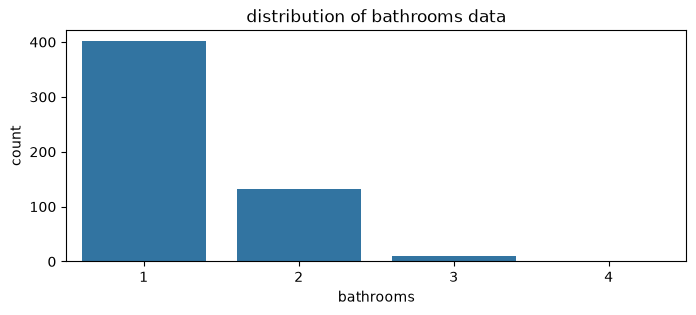

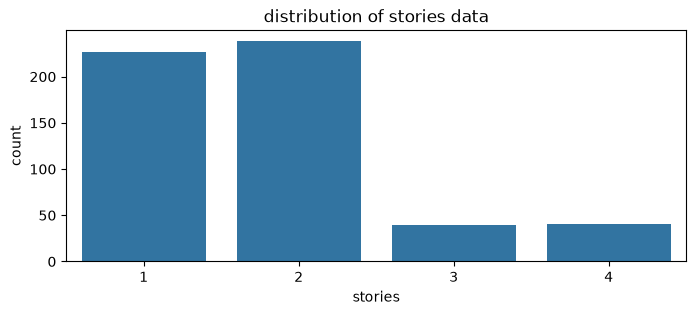

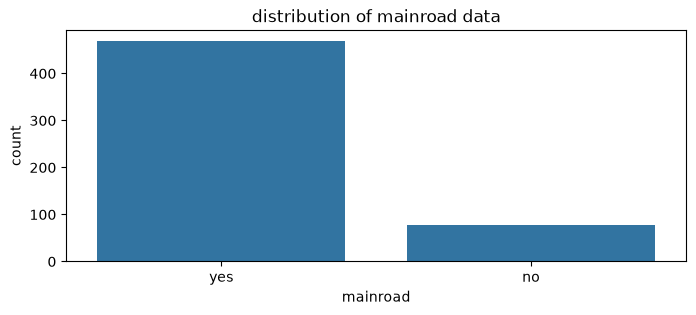

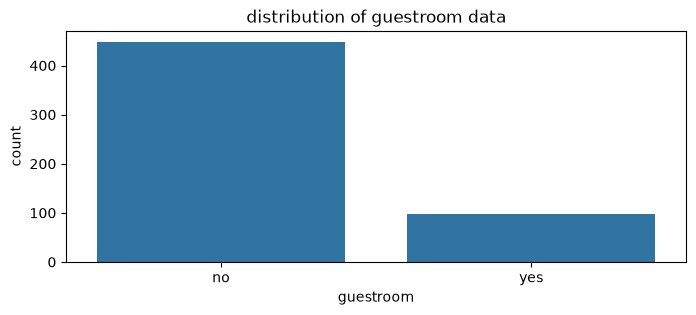

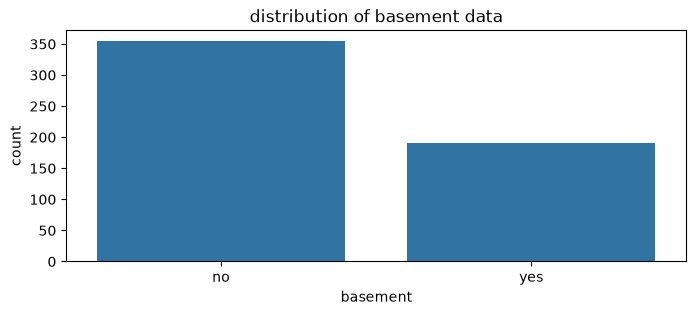

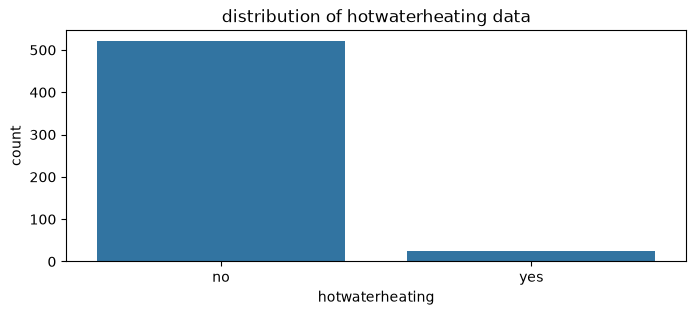

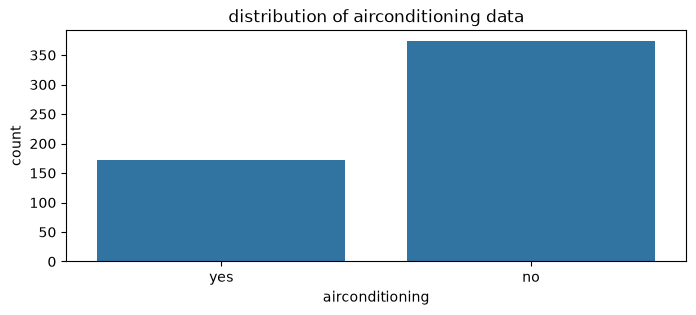

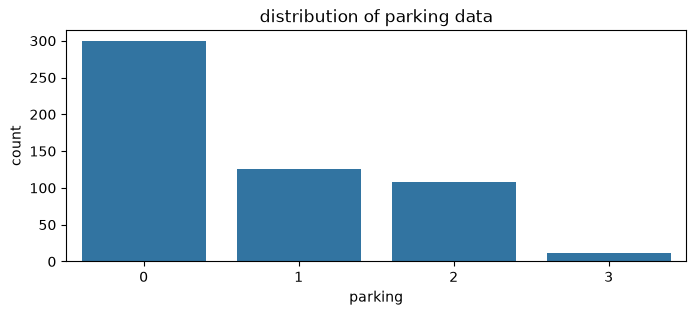

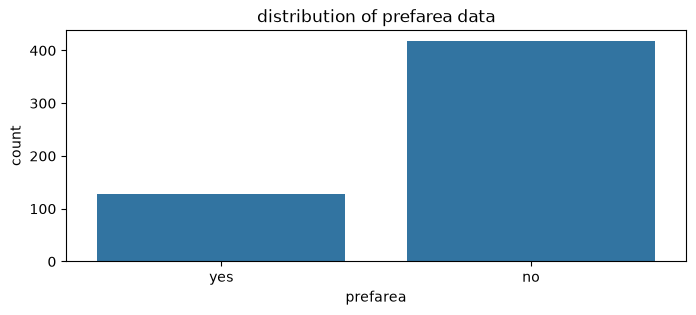

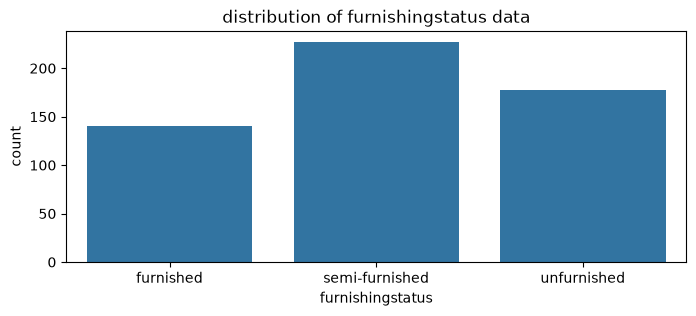

In [64]:
categorical_labels =[#'price', 'area', 
                     'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus']

for label in categorical_labels:
    plt.figure(figsize=(8,3))
    sns.countplot(x=label, data=df)
    plt.title(f"distribution of {label} data")
    plt.show()
    

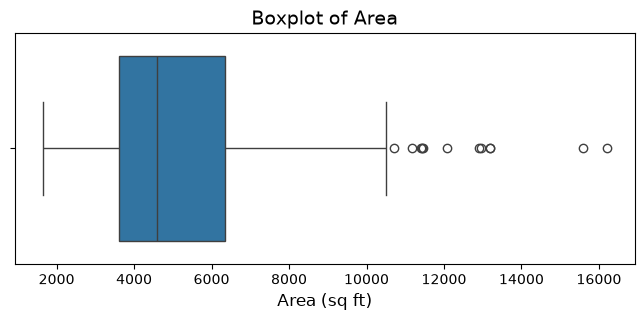

In [65]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df["area"])

plt.title("Boxplot of Area", fontsize=14)
plt.xlabel("Area (sq ft)", fontsize=12)
plt.show()

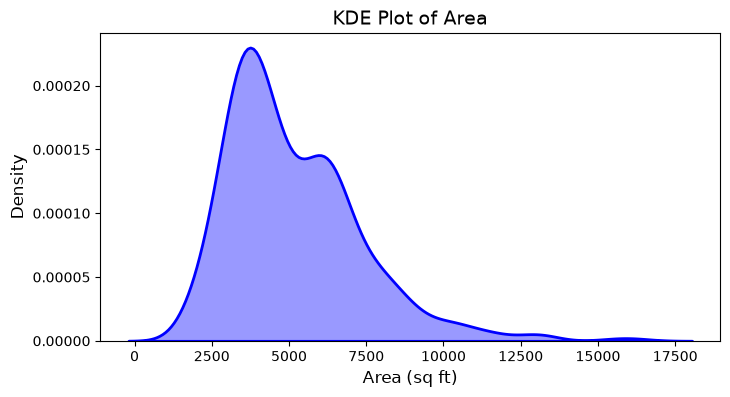

In [69]:
plt.figure(figsize=(8, 4))

sns.kdeplot(
    df['area'],
    fill=True,
    color="blue",
    alpha=0.4,
    linewidth=2
)

plt.title("KDE Plot of Area", fontsize=14)
plt.xlabel("Area (sq ft)", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.show()

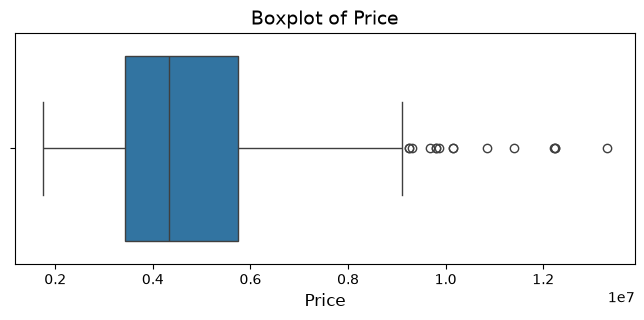

In [70]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df["price"])

plt.title("Boxplot of Price", fontsize=14)
plt.xlabel("Price", fontsize=12)
plt.show()

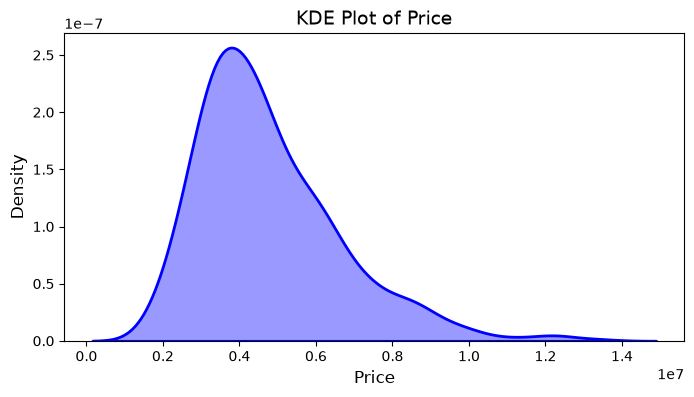

In [73]:
plt.figure(figsize=(8, 4))

sns.kdeplot(
    df['price'],
    fill=True,
    color="blue",
    alpha=0.4,
    linewidth=2
)

plt.title("KDE Plot of Price", fontsize=14)
plt.xlabel("Price", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.show()

**Analysis**

- When we look at the values of Area, the curve are not symmetric.
- They are skewed - meaning most values are clustered in a range, but a few extreme values (outliers) stretch the distribution toward one side.

**Why this is a problem for ML?**

- Many machine learning algorithms (like linear regression, logistic regression, KNN, neural networks) are sensitive to feature scaling.
- Outliers can distort scaling methods (like MinMaxScaler or StandardScaler) → making most data appear compressed into a small range.
- As a result, the model may give too much importance to these rare extreme values.

**Solution - using the clip function**

- clip() in pandas limits values to within a given range
- By clipping extreme values, You reduce skewness in the distribution.
- Scaling methods (like StandardScaler/MinMaxScaler) now work more effectively.
- The model becomes more robust and doesn’t overfit to rare outliers.

**Bivariate Analysis**
- Bivariate data refers to a dataset where each observation is associated with two different variables.

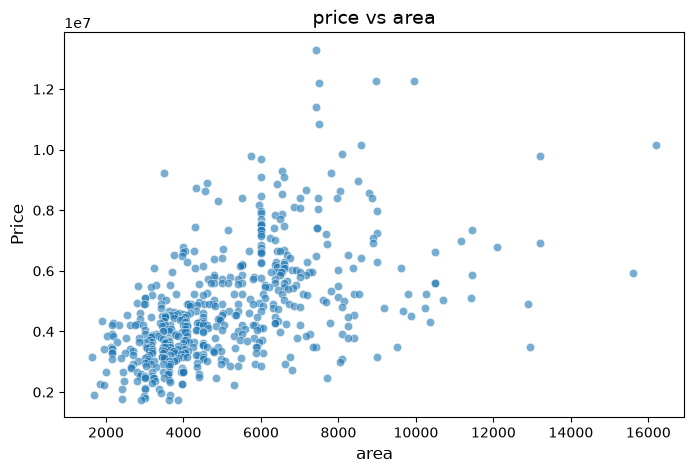

In [74]:
numeric_cols = ["area"]

for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=col, y='price', data=df, alpha=0.6)
    plt.title(f"price vs {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.show()
    

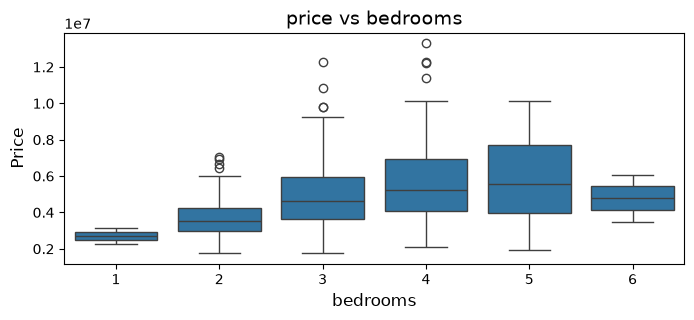

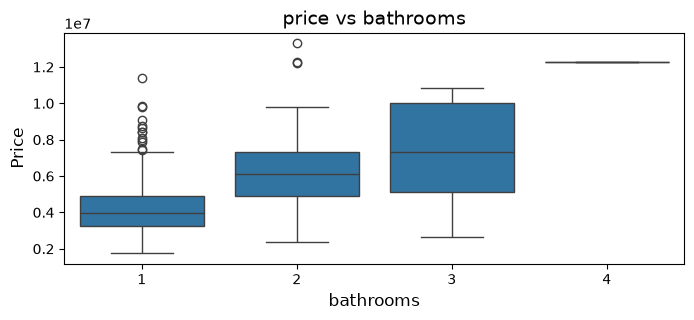

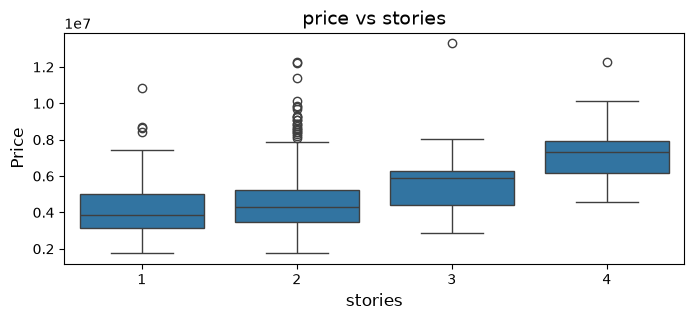

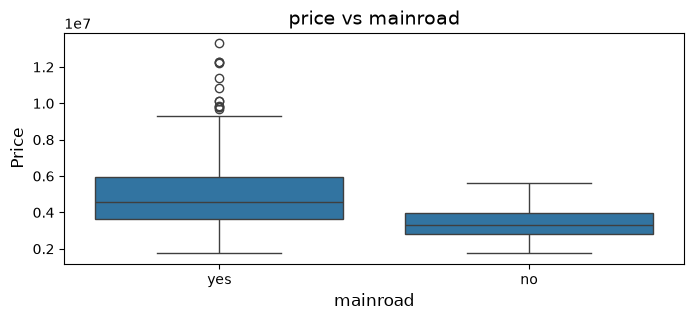

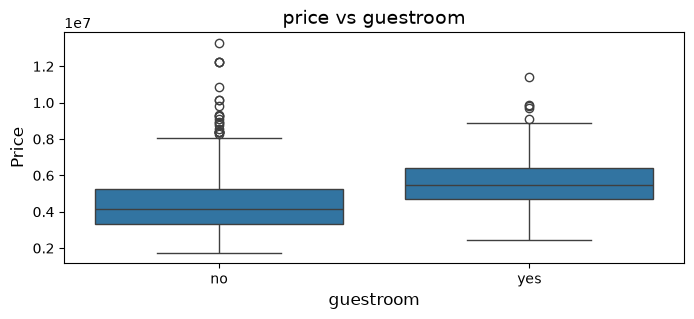

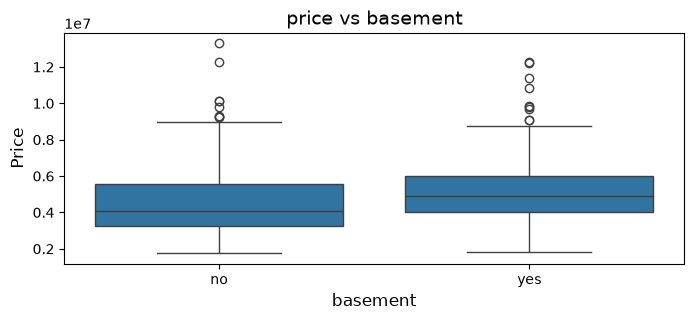

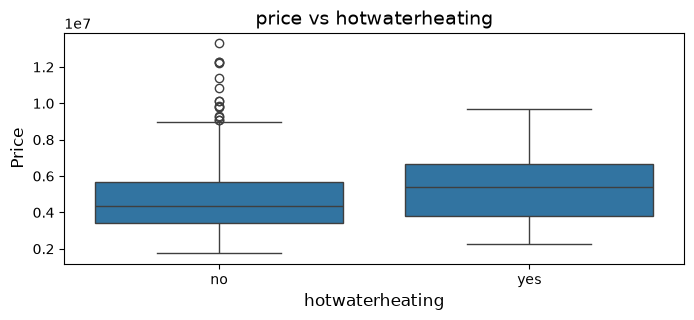

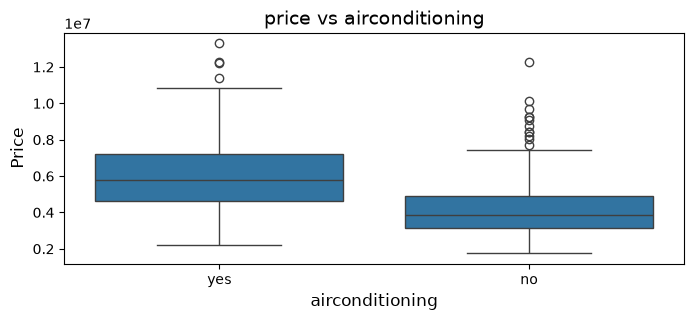

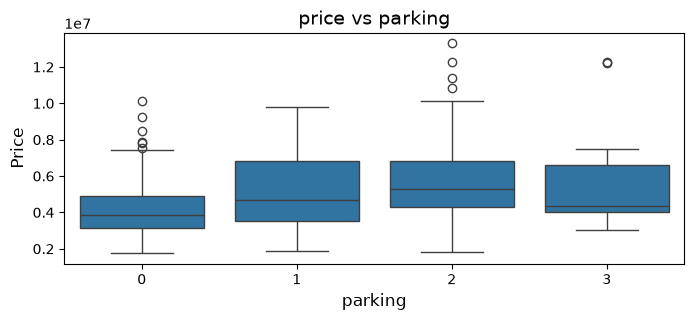

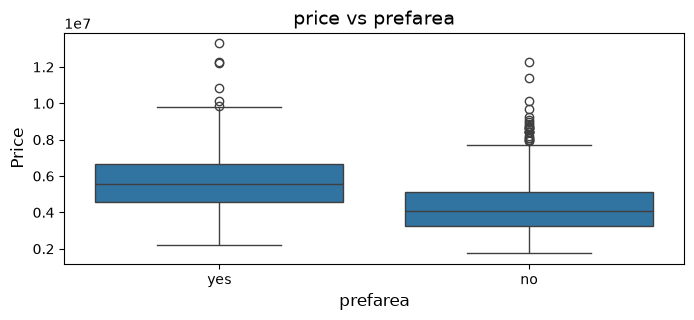

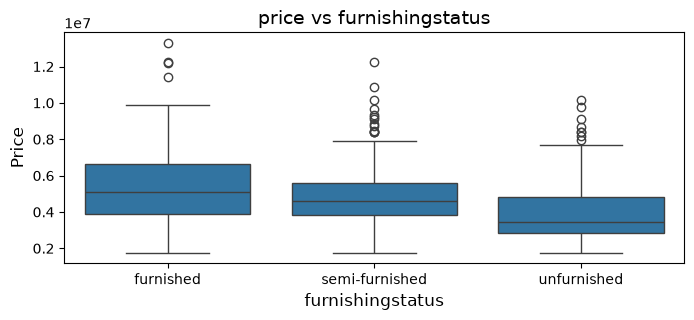

In [75]:
for col in categorical_labels:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=col, y='price', data=df)
    plt.title(f"price vs {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.show()

**Multivariate Analysis**
- Multivariate data refers to datasets where each observation is associated with more than two attributes.

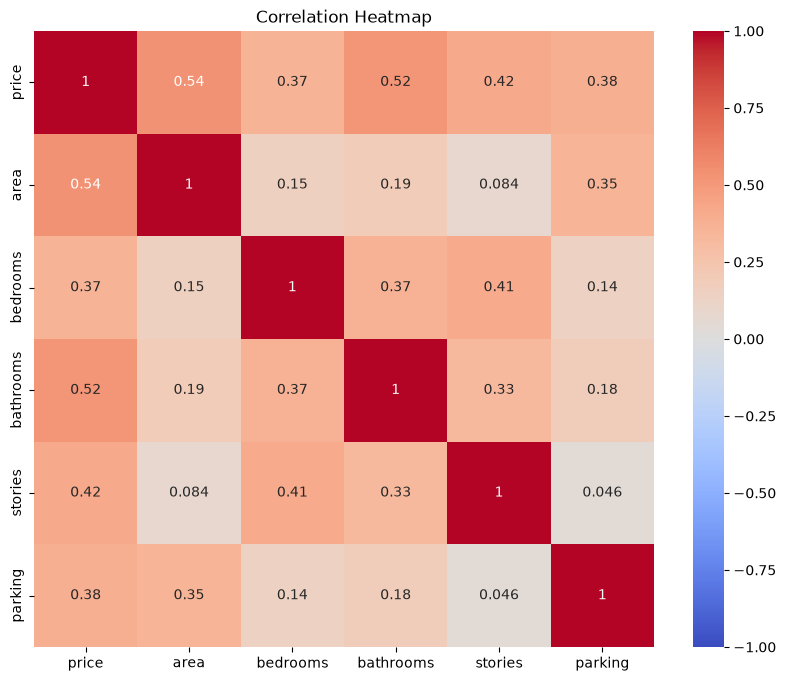

In [76]:
NumericalColumns=["price","area","bedrooms","bathrooms","stories","parking"]
plt.figure(figsize=(10, 8))
correlation_matrix = df[NumericalColumns].astype(float).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()